In [9]:
import oqupy
import oqupy.operators as op
import numpy as np
from oqupy.iTEBD_TEMPO_useoqupybath import iTEBD_TEMPO_oqupy
from oqupy.process_tensor import TTInvariantProcessTensor
from oqupy.tti_tempo import TTITempo
from oqupy.tti_tempo import TTITempoCounting
import matplotlib.pyplot as plt


from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from scipy.optimize import minimize,Bounds

pt_parameters = {'epsrel':10**(-7),
                 'alpha':0.1,
                 'omega_cutoff':1,                 
                 'temp':0.131,
                 'dt':0.25}

omega_cutoff = pt_parameters['omega_cutoff']
alpha = pt_parameters['alpha']
temperature = pt_parameters['temp']
epsrel = pt_parameters['epsrel']
# dt = 1./omega_cutoff/np.sqrt(3)
dt=pt_parameters['dt']

tcut=27

Rho_0=oqupy.operators.spin_dm('x+')

# spectral density (without cutoff)
def j(w):
    return 2*alpha*w


In [10]:
correlations = oqupy.PowerLawSD(alpha=alpha,
                                zeta=1,
                                cutoff=omega_cutoff,
                                cutoff_type='exponential',
                                temperature=temperature)
bath = oqupy.Bath(op.sigma("z")/2.0, correlations)
parameters=oqupy.TempoParameters(dt=dt,epsrel=epsrel,dkmax=int(tcut/dt)+1)

In [11]:
u=0.01
correlationscf=oqupy.bath_correlations.CustomCountingSD(j_function=j,cutoff=omega_cutoff,u=u,
                                                 cutoff_type='exponential',temperature=temperature)

bathcf = oqupy.Bath(op.sigma("z")/2.0, correlationscf)

In [12]:
# converged parameters for different protocol times 
protocol_times=[10,50,70,100,200]

pt_var=TTITempo(bath,start_time=0.0,parameters=parameters)
process_tensor_var = pt_var.get_process_tensor()

pt_varcf=TTITempoCounting(bathcf,start_time=0.0,parameters=parameters)
process_tensor_varcf = pt_varcf.get_process_tensor()


building influence functional:  21%|██        | 23/109 [00:00<00:00, 215.95it/s]

building influence functional: 100%|██████████| 109/109 [00:18<00:00,  5.84it/s]


rank  378


/Users/eoinoneill/Desktop/PhD/ITT-tempo/OQuPy/oqupy/bath_correlations.py:1165: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  im_int += integrate.quad(im_integrand,
building influence functional:  23%|██▎       | 25/109 [00:00<00:00, 248.87it/s]

building influence functional: 100%|██████████| 109/109 [00:18<00:00,  5.83it/s]


rank  386


In [13]:
# serialization of process tensor (optional)
import dill

# processtensor_simplemodel
file_name1='processtensor_simplemodel'
with open(file_name1,'wb') as f:
    dill.dump(process_tensor_var,f)

# processtensor_simplemodel
file_name2='processtensorCF_simplemodel'
with open(file_name2,'wb') as f:
    dill.dump(process_tensor_varcf,f)


--> Compute dynamics:
100.0%   40 of   40 [########################################] 00:00:02
Elapsed time: 2.0s
--> Compute dynamics:
100.0%   40 of   40 [########################################] 00:00:02
Elapsed time: 2.0s


/var/folders/s8/7dsl0tws32199pt1sh7flrsw0000gn/T/ipykernel_65201/1247475249.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


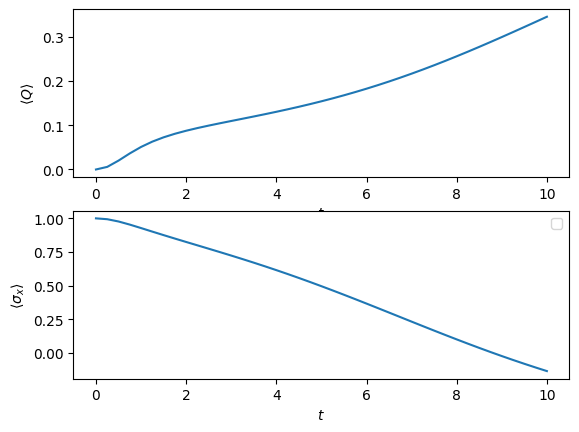

--> Compute dynamics:
100.0%  200 of  200 [########################################] 00:00:10
Elapsed time: 10.8s
--> Compute dynamics:
100.0%  200 of  200 [########################################] 00:00:11
Elapsed time: 11.7s


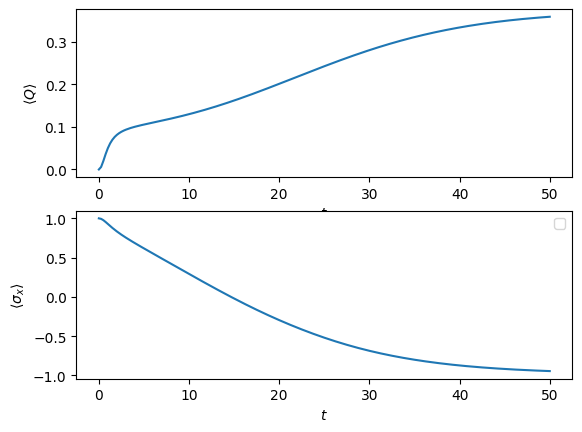

--> Compute dynamics:
 60.0%  168 of  280 [########################----------------] 00:00:09

KeyboardInterrupt: 

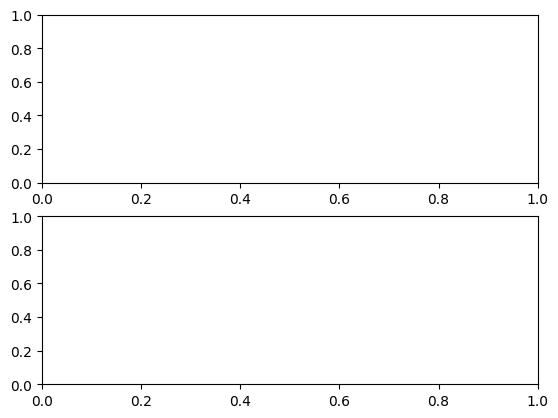

 60.0%  168 of  280 [########################----------------] 00:00:15

In [14]:

for t_prot in protocol_times:

   fig,axs=plt.subplots(2)

   num_steps=int(t_prot/dt)

   def hamiltonian_t(t):
      return pt_parameters['omega_cutoff']*op.sigma('x')*t/2 *(1/t_prot)

   system = oqupy.TimeDependentSystem(hamiltonian_t)

   # compute dynamics

   dynamics=oqupy.compute_dynamics(
   process_tensor=process_tensor_var,        
   system=system,
   initial_state=Rho_0,
   start_time=0,
   num_steps=num_steps)
   t, s_x = dynamics.expectations(op.sigma('x'), real=True)

   # compute heats

   dynamicscf = oqupy.compute_dynamics(
   process_tensor=process_tensor_varcf,        
   system=system,
   initial_state=Rho_0,
   start_time=0,
   num_steps=num_steps)

   heats=dynamicscf.states.trace(axis1=1,axis2=2).imag/u

   axs[0].plot(t,heats,label=t_prot)
   axs[0].set_xlabel(r'$t$')
   axs[0].set_ylabel(r'$\langle Q \rangle$')
   axs[1].plot(t,s_x)
   axs[1].set_xlabel(r'$t$')
   axs[1].set_ylabel(r'$\langle \sigma_x \rangle$')
   plt.legend()
   plt.show()


In [15]:
def discrete_hamiltonian(hx):
    return hx*op.sigma('x')/2
system = oqupy.ParameterizedSystem(discrete_hamiltonian)

target_derivative = -1j*np.identity(2)/u

 60.0%  168 of  280 [########################----------------] 00:00:16

In [16]:
# Cost Function
num_params=1

def heatandgrad(paras,process_tensor,num_steps):
    """""
    Take a numpy array [hx0, hz0, hx1, hz1, ...] over full timesteps and
    return the fidelity and gradient of the fidelity to the global target_derivative
    """

    # Reshape flat parameter list to form accepted by state_gradient: [[hx0,hz0],[hx1,hz1,]...]
    reshapedparas = [i for i in (paras.reshape((-1,num_params))).tolist() for j in range(2)]
    #parameter_list=np.array([itemopt_steps=[9] for pair in zip(paras[:num_steps],paras[num_steps:2*num_steps]) for item in pair])
    #reshapedparas = [i for i in (parameter_list.reshape((-1,num_params))).tolist() for j in range(2)]
    reshapedparas = np.array(reshapedparas)

    gradient_dict = oqupy.state_gradient(
        system=system,
        initial_state=Rho_0,
        target_derivative=target_derivative,
        process_tensors=[process_tensor],
        parameters=reshapedparas,
        num_steps=num_steps,
        progress_type='silent')
    
    fs=gradient_dict['final_state']
    gps=gradient_dict['gradient']

    heat=np.trace(fs).imag/u

    # Adding adjacent elements
    for i in range(0,gps.shape[0],2): 
        gps[i,:]=gps[i,:]+gps[i+1,:]
        
    gps=gps[0::2]

    x=[]
    for i in range(0,gps.shape[1]): 
        x.append(gps[:,i])
    
    gps=np.array(x)

    # Return the minus the gradient as infidelity is being minimized 
    return heat,(1.0*gps.reshape((-1)).real).tolist()

In [17]:
import time

opt_dict={protocol_times[0]:[],
                 protocol_times[1]:[], 
                 protocol_times[2]:[],
                 protocol_times[3]:[],
                 protocol_times[4]:[]}

min_heats=[]
opt_runtimes=[
]
#[10,20,50,70,100]
for t_prot in [10]:
    num_steps=int(t_prot/process_tensor_varcf.dt)
    hx=np.zeros(num_steps)
    parameter_list=[item for pair in zip(hx) for item in pair]
    start = time.time()
    
    optimization_result = minimize(
                            fun=heatandgrad,
                            x0=parameter_list,
                            args=(process_tensor_varcf,num_steps),
                            method='l-bfgs-b',
                            jac=True,
                            options = {'disp':True, 'gtol': 7e-04}
    )
    end = time.time()
    opt_runtimes.append(end-start)

    opt_dict[t_prot]=optimization_result

    min_heats.append(optimization_result.fun)

    print("The minimal heat was found to be : ",optimization_result.fun)

    print("The Jacobian was found to be : ",optimization_result.jac)

 60.0%  168 of  280 [########################----------------] 00:00:19RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           40     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  9.89721D-02    |proj g|=  1.24771D-02


 This problem is unconstrained.


 60.0%  168 of  280 [########################----------------] 00:00:23
At iterate    1    f=  6.22997D-02    |proj g|=  9.24117D-03
 60.0%  168 of  280 [########################----------------] 00:00:26
At iterate    2    f=  3.20125D-02    |proj g|=  5.09040D-03
 60.0%  168 of  280 [########################----------------] 00:00:29
At iterate    3    f=  1.97854D-02    |proj g|=  3.12376D-03
 60.0%  168 of  280 [########################----------------] 00:00:34
At iterate    4    f=  1.33103D-02    |proj g|=  1.58370D-03
 60.0%  168 of  280 [########################----------------] 00:00:38
At iterate    5    f=  1.03523D-02    |proj g|=  1.42513D-03
 60.0%  168 of  280 [########################----------------] 00:00:41
At iterate    6    f=  8.48377D-03    |proj g|=  9.66183D-04
 60.0%  168 of  280 [########################----------------] 00:00:45
At iterate    7    f=  6.51115D-03    |proj g|=  8.94755D-04
 60.0%  168 of  280 [########################----------------] 00:00:

 60.0%  168 of  280 [########################----------------] 00:11:29

In [51]:
print(min_heats)

[0.0018876721960780923, 0.0018876721960780923, -0.0074511897895117715, -0.012060719340017505, -0.015306091577869935]


 30.5%  122 of  400 [############----------------------------] 5 days, 23:42:05

In [42]:
opt_res=opt_dict[10]
print(opt_res)

[]


[-1.91719399 -3.76657528 -2.6583468  -1.12005286 -0.68250537 -0.92923346
 -1.18164621 -1.1798117  -1.00001016 -0.80585138 -0.69232593 -0.66622337
 -0.68931374 -0.72003377 -0.73371264 -0.72476323 -0.69971607 -0.66882865
 -0.64043013 -0.61880807 -0.60461971 -0.59631746 -0.59158341 -0.58829998
 -0.58499661 -0.5809161  -0.5758706  -0.57002613 -0.56370381 -0.55724088
 -0.55091117 -0.54489299 -0.53927265 -0.53406408 -0.52923252 -0.52471761
 -0.52045192 -0.51637166 -0.5124231  -0.50856603 -0.50477299 -0.50102671
 -0.4973177  -0.49364314 -0.49000358 -0.48640079 -0.48283868 -0.47932052
 -0.47584873 -0.47242606 -0.46905379 -0.46573314 -0.46246489 -0.45924843
 -0.45608371 -0.45297028 -0.44990695 -0.44689349 -0.44392868 -0.44101106
 -0.43813966 -0.43531244 -0.43252821 -0.42978707 -0.42708778 -0.4244274
 -0.42180501 -0.41921983 -0.41667062 -0.41415592 -0.41167282 -0.4092186
 -0.40679207 -0.4043934  -0.40202286 -0.3996788  -0.39735888 -0.39505951
 -0.39277319 -0.39050127 -0.38824873 -0.38601828 -0.3

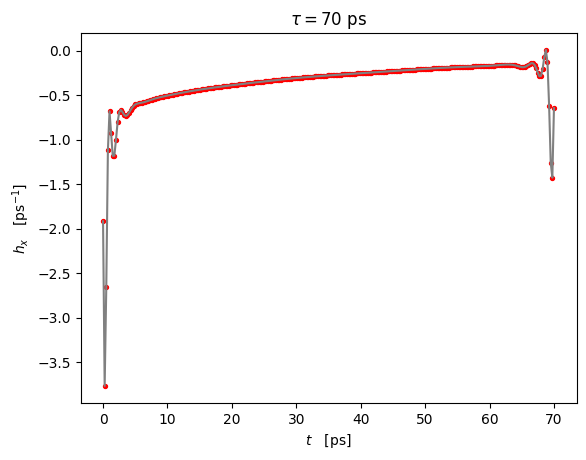

[-1.92349425 -3.77060455 -2.65327194 -1.13128545 -0.72027337 -0.9738226
 -1.21611274 -1.20255024 -1.01828535 -0.82705822 -0.72003024 -0.70012547
 -0.72689123 -0.75851958 -0.77148609 -0.76169465 -0.73665423 -0.7068208
 -0.68016281 -0.66043039 -0.64785379 -0.64068229 -0.63659814 -0.63360659
 -0.63039949 -0.62636285 -0.62140578 -0.61574091 -0.60969494 -0.60358416
 -0.59764886 -0.59203277 -0.58679253 -0.58192052 -0.5773704  -0.57307754
 -0.56897606 -0.56500896 -0.5611304  -0.55730843 -0.55352487 -0.54976978
 -0.54603951 -0.54233684 -0.53866633 -0.53503243 -0.53144135 -0.52789813
 -0.52440642 -0.52097006 -0.51759129 -0.51427183 -0.51101345 -0.50781656
 -0.50468167 -0.50160899 -0.49859795 -0.49564897 -0.49276177 -0.4899355
 -0.48716956 -0.48446294 -0.48181444 -0.47922376 -0.47669022 -0.47421222
 -0.47178764 -0.46941587 -0.46709638 -0.46482698 -0.46260765 -0.46043315
 -0.45829987 -0.45620761 -0.45415706 -0.45214867 -0.45018078 -0.4482493
 -0.44634224 -0.44445868 -0.44260334 -0.44077985 -0.438

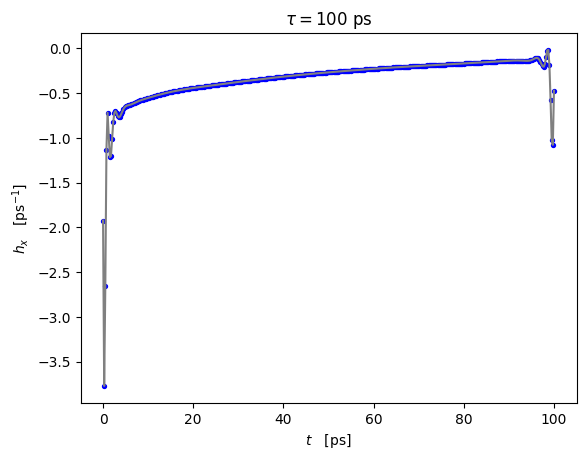

[-2.11389336 -4.04676007 -2.76920827 -1.25680362 -0.95822129 -1.24926607
 -1.43488406 -1.33458448 -1.10363685 -0.92435953 -0.85927673 -0.8746289
 -0.91084309 -0.92709072 -0.91189016 -0.87421896 -0.82975563 -0.79103065
 -0.76380365 -0.74792884 -0.74001204 -0.73592242 -0.73236275 -0.72745022
 -0.72061204 -0.71215833 -0.70280909 -0.69332875 -0.68431353 -0.67611437
 -0.66885426 -0.66248993 -0.65688024 -0.65184755 -0.64722254 -0.64286456
 -0.63867094 -0.63457888 -0.63055427 -0.6265839  -0.62267066 -0.61882258
 -0.61504845 -0.61135768 -0.60775646 -0.60424695 -0.60082906 -0.59750064
 -0.59425774 -0.59109554 -0.58800908 -0.5849931  -0.58204326 -0.57915613
 -0.57632813 -0.57355614 -0.57083789 -0.56817146 -0.56555548 -0.56298892
 -0.56047036 -0.55799907 -0.55557404 -0.55319345 -0.55085682 -0.54856457
 -0.54631541 -0.54410819 -0.54194297 -0.53981985 -0.5377397  -0.53570313
 -0.53370874 -0.53175518 -0.52984179 -0.52796894 -0.52613742 -0.52434771
 -0.52260175 -0.52089573 -0.51922344 -0.51758098 -0.

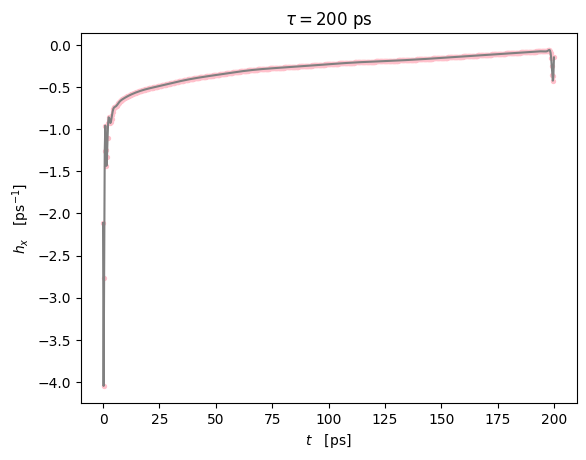

[-3.76828474 -5.47116192 -1.86008394 ... -0.04676978 -0.03665501
 -0.01414558]
[-3.76828474 -5.47116192 -1.86008394 ... -0.04676978 -0.03665501
 -0.01414558]


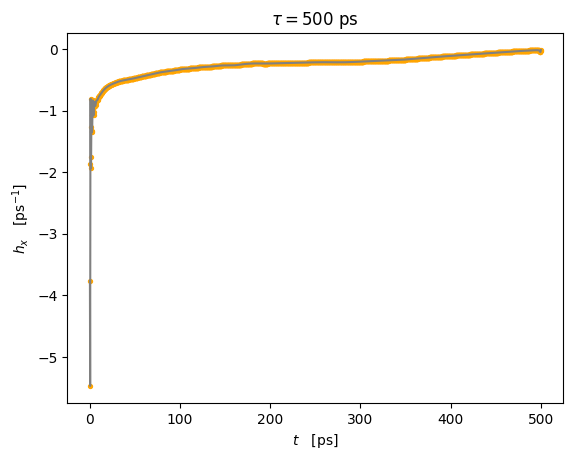

In [ ]:
cs=['red','blue','pink','orange','green']
controlfigs_dict={protocol_times[0]:[],
                 protocol_times[1]:[], 
                 protocol_times[2]:[],
                 protocol_times[3]:[],
                 protocol_times[4]:[]}

#[10,20,50,70,100]

for i,t_prot in enumerate([700,900,1000,1200]):
    opt_res=opt_dict[t_prot]
    print(opt_res.x)
    plt.title(r'$\tau={0}$ ps'.format(t_prot))
    plt.scatter(np.linspace(0,t_prot,len(opt_res.x)),opt_res.x,s=8,c=cs[i])
    plt.plot(np.linspace(0,t_prot,len(opt_res.x)),opt_res.x,c='gray')
    plt.xlabel(r'$t \quad[\text{ps}]$')
    plt.ylabel(r'$h_x \quad[\text{ps}^{-1}]$')
    print(opt_res.x)
    plt.show()
    

 30.5%  122 of  400 [############----------------------------] 6 days, 1:58:51

/var/folders/s8/7dsl0tws32199pt1sh7flrsw0000gn/T/ipykernel_1023/1781227843.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


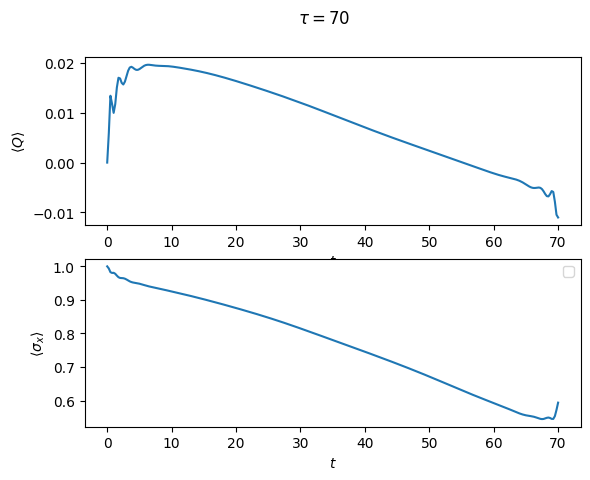

[[0.49996017-1.19257813e-12j 0.29697554-1.77787362e-12j]
 [0.29697554+2.52383028e-12j 0.49996017+2.11847263e-12j]]
 30.5%  122 of  400 [############----------------------------] 6 days, 2:00:27

/var/folders/s8/7dsl0tws32199pt1sh7flrsw0000gn/T/ipykernel_1023/1781227843.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


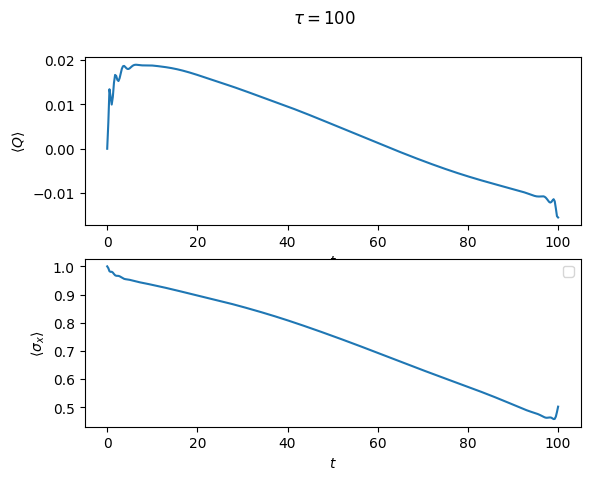

[[0.49994136-1.25164789e-12j 0.25107282-2.00621260e-12j]
 [0.25107282+2.10296984e-12j 0.49994136+2.41674767e-12j]]
 30.5%  122 of  400 [############----------------------------] 6 days, 2:03:06

/var/folders/s8/7dsl0tws32199pt1sh7flrsw0000gn/T/ipykernel_1023/1781227843.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


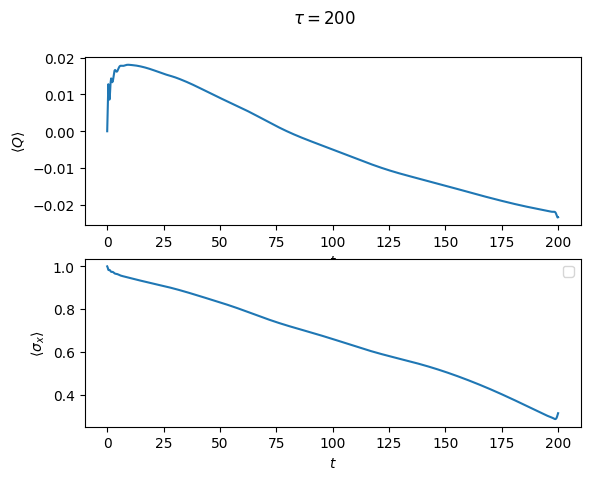

[[0.49987451-8.94184914e-13j 0.15654571-1.86703058e-12j]
 [0.15654571+6.36940003e-13j 0.49987451+2.62610285e-12j]]
 30.5%  122 of  400 [############----------------------------] 6 days, 2:10:00

/var/folders/s8/7dsl0tws32199pt1sh7flrsw0000gn/T/ipykernel_1023/1781227843.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


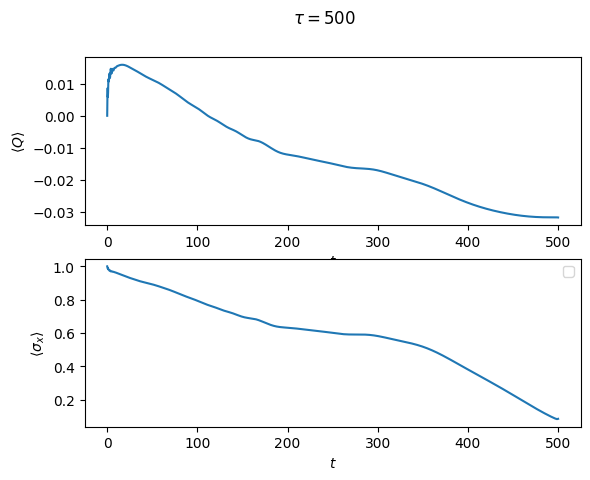

[[0.49967348+6.47954637e-13j 0.04316266-6.27952233e-13j]
 [0.04316266-7.21504561e-14j 0.49967348+3.17648804e-12j]]
(0.9990620976327236-0.0003184086455026981j)


In [ ]:
opt_grad_dict={protocol_times[0]:[],
                 protocol_times[1]:[], 
                 protocol_times[2]:[],
                 protocol_times[3]:[],
                 protocol_times[4]:[]}

for t_prot in [700,900,1000,1200]:
    fig,axs=plt.subplots(2)
    fig.suptitle(r'$\tau={0}$'.format(t_prot))

    num_steps=int(t_prot/process_tensor_varcf.dt)
    opt_res=opt_dict[t_prot]
    opt_parameters = reshapedparas = [i for i in (opt_res.x.reshape((-1,num_params))).tolist() for j in range(2)]
    opt_parameters=np.array(opt_parameters)

    grad_res_opt = oqupy.state_gradient(
        system=system,
        initial_state=Rho_0,
        target_derivative=target_derivative,
        process_tensors=[process_tensor_var],
        num_steps=num_steps,
        parameters=opt_parameters,
        progress_type='silent')

    dynamics=grad_res_opt['dynamics']
    t, s_x = dynamics.expectations(op.sigma('x'), real=True)

    grad_res_opt_cf = oqupy.state_gradient(
        system=system,
        initial_state=Rho_0,
        target_derivative=target_derivative,
        process_tensors=[process_tensor_varcf],
        num_steps=num_steps,
        parameters=opt_parameters,
        progress_type='silent')

    dynamicscf=grad_res_opt_cf['dynamics']
    heats=dynamicscf.states.trace(axis1=1,axis2=2).imag/u

    opt_grad_dict[t_prot]=grad_res_opt_cf

    axs[0].plot(t,heats,label=t_prot)
    axs[0].set_xlabel(r'$t$')
    axs[0].set_ylabel(r'$\langle Q \rangle$')
    axs[1].plot(t,s_x)
    axs[1].set_xlabel(r'$t$')
    axs[1].set_ylabel(r'$\langle \sigma_x \rangle$')
    plt.legend()
    plt.show()
    print(dynamics.states[-1])

print(np.trace(dynamicscf.states[-1]))
# Landauer erasure in the strong coupling regime inheritly requires a Non-Markovian control in order 

 30.5%  122 of  400 [############----------------------------] 6 days, 2:11:50

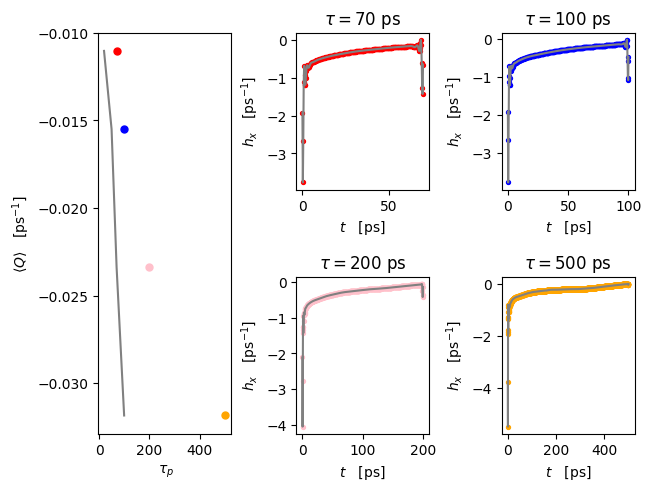

 30.5%  122 of  400 [############----------------------------] 6 days, 2:31:03

In [73]:
import matplotlib.gridspec as gridspec


cs=['red','blue','pink','orange','green']
final_heats=[]

fig = plt.figure(constrained_layout=True)
gs = gridspec.GridSpec(2, 3, figure=fig)

# Large plot on the left
ax1 = fig.add_subplot(gs[:, 0])

# 2x2 grid on the right
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 1])
ax5 = fig.add_subplot(gs[1, 2])

graphpositions={700:ax2,
                900:ax3,
                1000:ax4,
                1200:ax5}

u=0.01
for i,t_prot in enumerate([700,900,1000,1200]):
    dynamicscf=opt_grad_dict[t_prot]['dynamics']
    heats=dynamicscf.states.trace(axis1=1,axis2=2).imag/u
    final_heats.append(heats[-1])
    ax1.scatter(t_prot,heats[-1],s=25,c=cs[i])
    axs=graphpositions[t_prot]
    opt_res=opt_dict[t_prot]
    axs.set_title(r'$\tau={0}$ ps'.format(t_prot))
    axs.scatter(np.linspace(0,t_prot,len(opt_res.x)),opt_res.x,s=8,c=cs[i])
    axs.plot(np.linspace(0,t_prot,len(opt_res.x)),opt_res.x,c='gray')
    axs.set_xlabel(r'$t \quad[\text{ps}]$')
    axs.set_ylabel(r'$h_x \quad[\text{ps}^{-1}]$')


ax1.plot([20,50,70,100],final_heats,c='gray')
ax1.set_xlabel(r' $\tau_p$ ')
ax1.set_ylabel(r'$\langle Q \rangle \quad[\text{ps}^{-1}]$')
plt.show()

# course graining
# 

In [47]:
from scipy.optimize import curve_fit

def control_analytic(t, T, alpha, omega, sigma):
    """
    Analytic bang-bang-inspired control function.

    Parameters:
    - t     : float or ndarray, time(s) at which to evaluate the control
    - T     : float, total duration of the protocol
    - alpha : float, slope of the linear ramp in the middle
    - omega : float, frequency of oscillations at the edges
    - sigma : float, width of the envelope for oscillations (smaller = more localized)

    Returns:
    - u(t) : control value(s) at time t
    """
    t = np.asarray(t)
    A_t = np.exp(-((t - T/2) / sigma) ** 4)
    B_t = alpha * t
    return A_t * np.sin(omega * t) + B_t

t_prot=20
t=np.linspace(0,t_prot,len(opt_dict[t_prot].x))
popt,pcov=curve_fit(control_analytic,t,opt_dict[t_prot].x)

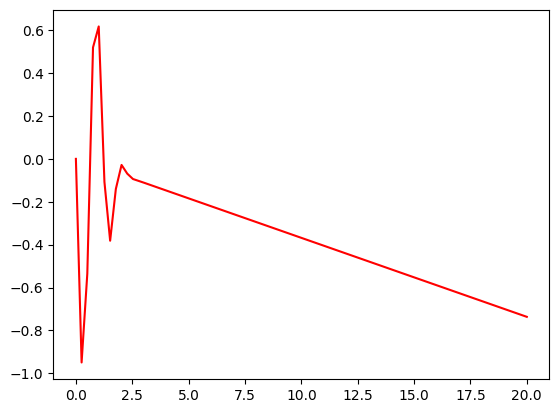

In [48]:
plt.plot(t ,control_analytic(t, *popt), 'r-')

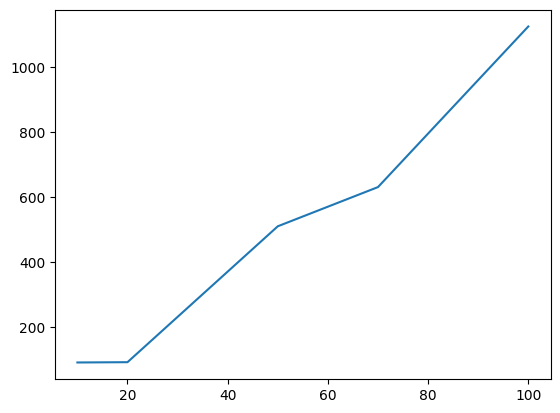

 30.5%  122 of  400 [############----------------------------] 5 days, 23:39:31

In [49]:
plt.plot([10,20,50,70,100],opt_runtimes)